# Projet SM604 - De la classification des chiffres manuscrits a la detection de cancers du sein
## Mathematiques pour le Machine Learning - EFREI Paris 2025-2026
### Sabrina El Hassani, Aude Labat, Thomas Duriaud, Paul Fontaine, Evan Ladeira

---

## Partie 2 - La base de donnees CIFAR-10

Ce notebook est organise en quatre sections :

**Section 2.1** Chargement et visualisation de CIFAR-10

**Section 2.2** Travail preliminaire : architectures MNIST adaptees (grayscale et RGB)

**Section 2.3** Filtres de convolution implementes from scratch (K1 a K6)

**Section 2.4** CNN complet via PyTorch (Option B)

Les fonctions communes (softmax, cross-entropy, forward, backward, train) sont importees depuis `utils.py`. Placer ce fichier dans le meme dossier que ce notebook.

---
## Section 2.1 - Chargement de CIFAR-10

CIFAR-10 contient 60 000 images couleur 32x32 pixels reparties en 10 classes. Chaque image est representee par une matrice de taille 32x32x3 (hauteur x largeur x canaux RGB). On charge le dataset via HuggingFace qui le met en cache localement apres le premier telechargement.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from utils import *

np.random.seed(42)
print("Imports OK")

c:\Users\SURFACE\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


### Chargement

On charge via HuggingFace et on convertit immediatement en NumPy. Le dataset est mis en cache : le second lancement est instantane.

In [2]:
print("Chargement CIFAR-10 depuis HuggingFace...")
ds = load_dataset("cifar10")

# Conversion en arrays NumPy
# HuggingFace renvoie des images PIL : on les convertit en arrays (32, 32, 3) uint8
X_train_raw = np.array([np.array(img) for img in ds["train"]["img"]])  # (50000, 32, 32, 3)
y_train     = np.array(ds["train"]["label"])                           # (50000,)
X_test_raw  = np.array([np.array(img) for img in ds["test"]["img"]])   # (10000, 32, 32, 3)
y_test      = np.array(ds["test"]["label"])                            # (10000,)

# Labels : 0=avion 1=automobile 2=oiseau 3=chat 4=cerf 5=chien 6=grenouille 7=cheval 8=bateau 9=camion
CLASSES = ["avion", "automobile", "oiseau", "chat", "cerf",
           "chien", "grenouille", "cheval", "bateau", "camion"]

print(f"Train : {X_train_raw.shape}  | 50 000 images 32x32 RGB")
print(f"Test  : {X_test_raw.shape}   | 10 000 images 32x32 RGB")
print(f"Pixels : min={X_train_raw.min()}, max={X_train_raw.max()}")
print("\nDistribution des classes (train) :")
for k in range(10):
    n = int(np.sum(y_train == k))
    print(f"  {CLASSES[k]:<12} : {n} ({100*n/len(y_train):.1f}%)")

Chargement CIFAR-10 depuis HuggingFace...


Train : (50000, 32, 32, 3)  | 50 000 images 32x32 RGB
Test  : (10000, 32, 32, 3)   | 10 000 images 32x32 RGB
Pixels : min=0, max=255

Distribution des classes (train) :
  avion        : 5000 (10.0%)
  automobile   : 5000 (10.0%)
  oiseau       : 5000 (10.0%)
  chat         : 5000 (10.0%)
  cerf         : 5000 (10.0%)
  chien        : 5000 (10.0%)
  grenouille   : 5000 (10.0%)
  cheval       : 5000 (10.0%)
  bateau       : 5000 (10.0%)
  camion       : 5000 (10.0%)


### Visualisation

On affiche 10 images aleatoires pour verifier le chargement. Les images sont volontairement en basse resolution (32x32) : c'est voulu par le dataset.

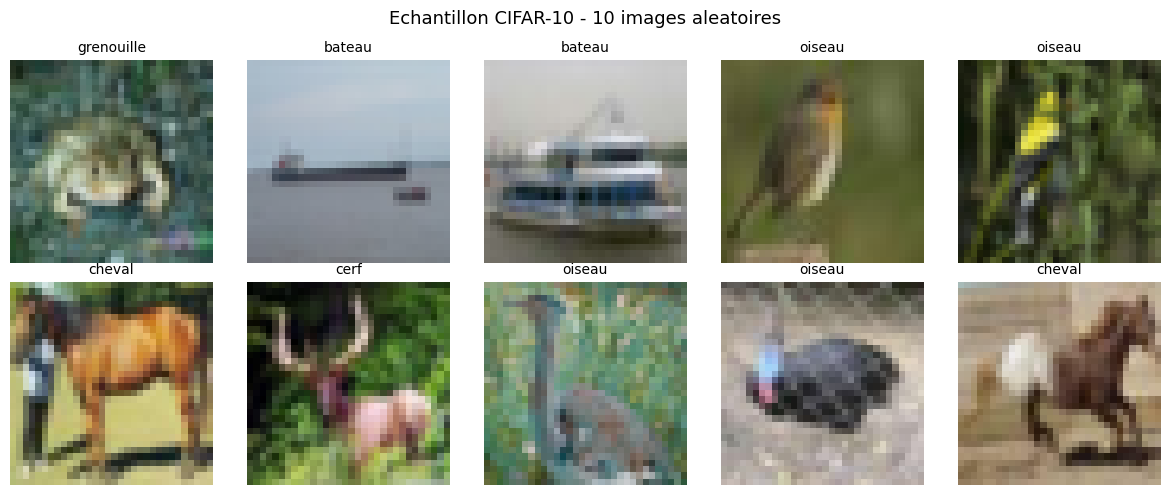

In [3]:
np.random.seed(42)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax in axes.flat:
    idx = np.random.randint(0, len(X_train_raw))
    ax.imshow(X_train_raw[idx])                    # shape (32, 32, 3) : matplotlib accepte directement
    ax.set_title(CLASSES[y_train[idx]], fontsize=10)
    ax.axis("off")
plt.suptitle("Echantillon CIFAR-10 - 10 images aleatoires", fontsize=13)
plt.tight_layout()
plt.savefig("cifar10_echantillon.png", dpi=100, bbox_inches="tight")
plt.show()

---
## Section 2.2 - Travail preliminaire

On applique les trois architectures de la Partie 1 (lineaire, H=1, H=2) a CIFAR-10 en adaptant uniquement la dimension d'entree. Deux etudes successives :

**Etude 1 - Grayscale** : on fusionne les 3 canaux RGB en une seule valeur par pixel par la formule standard ITU-R BT.601 : $x_j = 0.299 R_j + 0.587 G_j + 0.114 B_j$. Chaque image devient $\vec{x} \in \mathbb{R}^{1024}$.

**Etude 2 - RGB** : on conserve les 3 canaux et on les aplatit bout a bout. Chaque image devient $\vec{x} \in \mathbb{R}^{3072}$.

Toutes les fonctions (softmax, cross-entropy, forward, backward, train) sont importees depuis `utils.py`.

### Preparation des etiquettes one-hot

In [4]:
# one_hot est importe depuis utils.py
Y_train = one_hot(y_train)   # (50000, 10)
Y_test  = one_hot(y_test)    # (10000, 10)
print(f"Y_train : {Y_train.shape}  Y_test : {Y_test.shape}")

Y_train : (50000, 10)  Y_test : (10000, 10)


---
### Etude 1 - Conversion en niveaux de gris

La formule du sujet est la suivante. Pour chaque pixel $j$ parmi les 1024 :
$$x_j = 0.299 R_j + 0.587 G_j + 0.114 B_j$$

On constate que l'oeil humain est plus sensible au vert (0.587) qu'au rouge (0.299) et peu sensible au bleu (0.114). On aplatit ensuite chaque image en vecteur de 1024 valeurs et on normalise entre 0 et 1 en divisant par 255.

X_train_gray : (50000, 1024)
X_test_gray  : (10000, 1024)
Pixels normalises : min=0.000  max=1.000


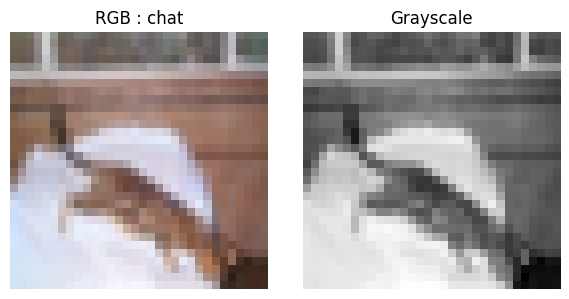

In [5]:
def rgb_to_grayscale(X_rgb):
    """
    Convertit un batch d'images RGB en niveaux de gris.
    Applique la formule x_j = 0.299*R_j + 0.587*G_j + 0.114*B_j pixel par pixel.

    X_rgb   : (n, 32, 32, 3) uint8 valeurs entre 0 et 255
    Retourne: (n, 1024) float valeurs entre 0 et 1
    """
    R = X_rgb[:, :, :, 0].astype(float)              # canal rouge  (n, 32, 32)
    G = X_rgb[:, :, :, 1].astype(float)              # canal vert   (n, 32, 32)
    B = X_rgb[:, :, :, 2].astype(float)              # canal bleu   (n, 32, 32)
    gray = 0.299 * R + 0.587 * G + 0.114 * B        # fusion en niveaux de gris (n, 32, 32)
    return gray.reshape(len(X_rgb), -1) / 255.0      # aplatissement (n, 1024) + normalisation


X_train_gray = rgb_to_grayscale(X_train_raw)   # (50000, 1024)
X_test_gray  = rgb_to_grayscale(X_test_raw)    # (10000, 1024)

print(f"X_train_gray : {X_train_gray.shape}")
print(f"X_test_gray  : {X_test_gray.shape}")
print(f"Pixels normalises : min={X_train_gray.min():.3f}  max={X_train_gray.max():.3f}")

# Verification visuelle : meme image avant et apres conversion
idx_chat = int(np.where(y_train == 3)[0][0])   # premier chat du dataset
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train_raw[idx_chat])
axes[0].set_title(f"RGB : {CLASSES[y_train[idx_chat]]}")
axes[0].axis("off")
axes[1].imshow(X_train_gray[idx_chat].reshape(32, 32), cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("comparaison_gray.png", dpi=100, bbox_inches="tight")
plt.show()

### Modele lineaire - Grayscale

Architecture : $o = A\vec{x} + b$ avec $A \in \mathbb{R}^{10 \times 1024}$ et $b \in \mathbb{R}^{10}$.
Nombre de parametres : $10 \times 1024 + 10 = 10\,250$.
Seule la dimension d'entree change par rapport a la Partie 1 (784 -> 1024).

In [6]:
print("=" * 55)
print(f"Modele lineaire - Grayscale | Parametres : {10*1024 + 10:,}")
print("=" * 55)

# train_lin est importe depuis utils.py
A_lin_g, b_lin_g, loss_lin_g, etr_lin_g, ete_lin_g = train_lin(
    X_train_gray, Y_train, y_train,
    X_test_gray,  y_test,
    n_input=1024, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_lin_g[-1]*100:.2f}%  |  Test : {ete_lin_g[-1]*100:.2f}%  |  Ecart : {abs(etr_lin_g[-1]-ete_lin_g[-1])*100:.2f}%")

Modele lineaire - Grayscale | Parametres : 10,250
  Epoch   0 | Loss=2.4260 | Train=76.45% | Test=76.59%
  Epoch   5 | Loss=2.7537 | Train=79.77% | Test=80.25%
  Epoch  10 | Loss=2.7651 | Train=82.66% | Test=83.01%
  Epoch  15 | Loss=3.4529 | Train=78.97% | Test=80.41%
  Epoch  20 | Loss=2.6690 | Train=82.27% | Test=83.37%
  Epoch  25 | Loss=2.4104 | Train=77.07% | Test=78.27%
  Epoch  30 | Loss=2.5544 | Train=78.11% | Test=78.94%
  Epoch  35 | Loss=2.3700 | Train=74.37% | Test=76.09%
  Epoch  40 | Loss=2.8222 | Train=80.96% | Test=81.94%
  Epoch  45 | Loss=2.8161 | Train=84.40% | Test=85.31%
  Epoch  50 | Loss=2.3182 | Train=74.40% | Test=76.13%
  Arret : 50 epochs atteintes

Resultat final :
  Train : 74.40%  |  Test : 76.13%  |  Ecart : 1.73%


### Modele H=1 - Grayscale

Architecture : une couche cachee de 128 neurones avec ReLU.
Nombre de parametres : $128 \times 1024 + 128 + 10 \times 128 + 10 = 132\,490$.

In [7]:
print("=" * 55)
print(f"Modele H=1 - Grayscale (p1=128) | Parametres : {128*1024+128+10*128+10:,}")
print("=" * 55)

A1_h1_g, b1_h1_g, A2_h1_g, b2_h1_g, loss_h1_g, etr_h1_g, ete_h1_g = train_h1(
    X_train_gray, Y_train, y_train,
    X_test_gray,  y_test,
    n_input=1024, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h1_g[-1]*100:.2f}%  |  Test : {ete_h1_g[-1]*100:.2f}%  |  Ecart : {abs(etr_h1_g[-1]-ete_h1_g[-1])*100:.2f}%")

Modele H=1 - Grayscale (p1=128) | Parametres : 132,490
  Epoch   0 | Loss=2.1142 | Train=79.25% | Test=79.41%
  Epoch   5 | Loss=1.8808 | Train=66.56% | Test=67.34%
  Epoch  10 | Loss=1.8023 | Train=64.10% | Test=64.71%
  Epoch  15 | Loss=1.8013 | Train=64.88% | Test=66.48%
  Epoch  20 | Loss=1.8239 | Train=63.88% | Test=65.52%
  Epoch  25 | Loss=1.6716 | Train=58.50% | Test=61.86%
  Epoch  30 | Loss=1.6760 | Train=59.90% | Test=62.72%
  Epoch  35 | Loss=1.7796 | Train=62.54% | Test=65.58%
  Early stopping epoch 36

Resultat final :
  Train : 66.41%  |  Test : 68.87%  |  Ecart : 2.46%


### Modele H=2 - Grayscale

Architecture : deux couches cachees (128 puis 64 neurones) avec ReLU.
Nombre de parametres : $128 \times 1024 + 128 + 64 \times 128 + 64 + 10 \times 64 + 10 = 141\,002$.

In [8]:
print("=" * 55)
print(f"Modele H=2 - Grayscale (p1=128, p2=64) | Parametres : {128*1024+128+64*128+64+10*64+10:,}")
print("=" * 55)

A1_h2_g, b1_h2_g, A2_h2_g, b2_h2_g, A3_h2_g, b3_h2_g, \
    loss_h2_g, etr_h2_g, ete_h2_g = train_h2(
    X_train_gray, Y_train, y_train,
    X_test_gray,  y_test,
    n_input=1024, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h2_g[-1]*100:.2f}%  |  Test : {ete_h2_g[-1]*100:.2f}%  |  Ecart : {abs(etr_h2_g[-1]-ete_h2_g[-1])*100:.2f}%")

Modele H=2 - Grayscale (p1=128, p2=64) | Parametres : 140,106
  Epoch   0 | Loss=2.3020 | Train=90.00% | Test=90.00%
  Epoch   5 | Loss=2.0483 | Train=75.24% | Test=75.05%
  Epoch  10 | Loss=1.9423 | Train=69.48% | Test=69.55%
  Epoch  15 | Loss=1.8391 | Train=65.59% | Test=66.25%
  Epoch  20 | Loss=1.7535 | Train=62.47% | Test=63.67%
  Epoch  25 | Loss=1.8367 | Train=64.92% | Test=65.78%
  Epoch  30 | Loss=1.8115 | Train=64.19% | Test=65.19%
  Epoch  35 | Loss=1.6401 | Train=58.55% | Test=61.39%
  Epoch  40 | Loss=1.6509 | Train=58.49% | Test=61.66%
  Epoch  45 | Loss=1.6147 | Train=57.93% | Test=61.67%
  Early stopping epoch 46

Resultat final :
  Train : 62.40%  |  Test : 65.64%  |  Ecart : 3.24%


---
### Etude 2 - Images RGB aplaties

On conserve les 3 canaux et on les met bout a bout dans l'ordre R, G, B :
$$\vec{x} = [R_1, ..., R_{1024}, G_1, ..., G_{1024}, B_1, ..., B_{1024}] \in \mathbb{R}^{3072}$$

On normalise entre 0 et 1 en divisant par 255.

In [9]:
def rgb_to_flat(X_rgb):
    """
    Aplatit les images RGB en vecteurs 3072 et normalise.
    On transpose d'abord en (n, 3, 32, 32) pour avoir l'ordre R puis G puis B.

    X_rgb   : (n, 32, 32, 3) uint8
    Retourne: (n, 3072) float entre 0 et 1
    """
    X_chw  = X_rgb.transpose(0, 3, 1, 2).astype(float)   # (n, 3, 32, 32) canaux en premier
    X_flat = X_chw.reshape(len(X_rgb), -1)                # (n, 3072)
    return X_flat / 255.0


X_train_rgb = rgb_to_flat(X_train_raw)   # (50000, 3072)
X_test_rgb  = rgb_to_flat(X_test_raw)    # (10000, 3072)

print(f"X_train_rgb : {X_train_rgb.shape}")
print(f"X_test_rgb  : {X_test_rgb.shape}")
print(f"Pixels normalises : min={X_train_rgb.min():.3f}  max={X_train_rgb.max():.3f}")

X_train_rgb : (50000, 3072)
X_test_rgb  : (10000, 3072)
Pixels normalises : min=0.000  max=1.000


### Modele lineaire - RGB

Meme architecture qu'en grayscale, mais $A \in \mathbb{R}^{10 \times 3072}$.
Nombre de parametres : $10 \times 3072 + 10 = 30\,730$.

In [10]:
print("=" * 55)
print(f"Modele lineaire - RGB | Parametres : {10*3072 + 10:,}")
print("=" * 55)

A_lin_r, b_lin_r, loss_lin_r, etr_lin_r, ete_lin_r = train_lin(
    X_train_rgb, Y_train, y_train,
    X_test_rgb,  y_test,
    n_input=3072, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_lin_r[-1]*100:.2f}%  |  Test : {ete_lin_r[-1]*100:.2f}%  |  Ecart : {abs(etr_lin_r[-1]-ete_lin_r[-1])*100:.2f}%")

Modele lineaire - RGB | Parametres : 30,730
  Epoch   0 | Loss=8.1906 | Train=79.15% | Test=79.34%
  Epoch   5 | Loss=9.3662 | Train=78.48% | Test=78.36%
  Epoch  10 | Loss=6.2898 | Train=69.45% | Test=69.56%
  Epoch  15 | Loss=8.9147 | Train=78.13% | Test=78.68%
  Epoch  20 | Loss=7.8251 | Train=76.03% | Test=76.72%
  Epoch  25 | Loss=8.9378 | Train=76.82% | Test=77.81%
  Epoch  30 | Loss=5.8161 | Train=69.88% | Test=70.83%
  Epoch  35 | Loss=6.0126 | Train=72.13% | Test=73.55%
  Epoch  40 | Loss=6.8742 | Train=77.15% | Test=77.62%
  Epoch  45 | Loss=6.3784 | Train=73.90% | Test=75.33%
  Epoch  50 | Loss=9.0716 | Train=79.33% | Test=80.01%
  Arret : 50 epochs atteintes

Resultat final :
  Train : 79.33%  |  Test : 80.01%  |  Ecart : 0.68%


### Modele H=1 - RGB

Nombre de parametres : $128 \times 3072 + 128 + 10 \times 128 + 10 = 405\,130$.

In [11]:
print("=" * 55)
print(f"Modele H=1 - RGB (p1=128) | Parametres : {128*3072+128+10*128+10:,}")
print("=" * 55)

A1_h1_r, b1_h1_r, A2_h1_r, b2_h1_r, loss_h1_r, etr_h1_r, ete_h1_r = train_h1(
    X_train_rgb, Y_train, y_train,
    X_test_rgb,  y_test,
    n_input=3072, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h1_r[-1]*100:.2f}%  |  Test : {ete_h1_r[-1]*100:.2f}%  |  Ecart : {abs(etr_h1_r[-1]-ete_h1_r[-1])*100:.2f}%")

Modele H=1 - RGB (p1=128) | Parametres : 394,634
  Epoch   0 | Loss=1.9582 | Train=70.01% | Test=70.29%
  Epoch   5 | Loss=1.7599 | Train=63.52% | Test=63.69%
  Epoch  10 | Loss=1.8178 | Train=64.68% | Test=65.13%
  Epoch  15 | Loss=1.5564 | Train=54.13% | Test=56.23%
  Epoch  20 | Loss=1.4686 | Train=53.26% | Test=55.30%
  Epoch  25 | Loss=1.4764 | Train=52.74% | Test=55.65%
  Epoch  30 | Loss=1.3671 | Train=47.99% | Test=51.62%
  Epoch  35 | Loss=1.4307 | Train=49.58% | Test=53.95%
  Epoch  40 | Loss=1.2736 | Train=45.53% | Test=50.58%
  Epoch  45 | Loss=1.4228 | Train=51.28% | Test=56.28%
  Epoch  50 | Loss=1.4895 | Train=53.90% | Test=59.34%
  Arret : 50 epochs atteintes

Resultat final :
  Train : 53.90%  |  Test : 59.34%  |  Ecart : 5.44%


### Modele H=2 - RGB

Nombre de parametres : $128 \times 3072 + 128 + 64 \times 128 + 64 + 10 \times 64 + 10 = 413\,642$.

In [12]:
print("=" * 55)
print(f"Modele H=2 - RGB (p1=128, p2=64) | Parametres : {128*3072+128+64*128+64+10*64+10:,}")
print("=" * 55)

A1_h2_r, b1_h2_r, A2_h2_r, b2_h2_r, A3_h2_r, b3_h2_r, \
    loss_h2_r, etr_h2_r, ete_h2_r = train_h2(
    X_train_rgb, Y_train, y_train,
    X_test_rgb,  y_test,
    n_input=3072, lr=0.1, batch_size=256, seuil=1e-4, max_epochs=50
)

print(f"\nResultat final :")
print(f"  Train : {etr_h2_r[-1]*100:.2f}%  |  Test : {ete_h2_r[-1]*100:.2f}%  |  Ecart : {abs(etr_h2_r[-1]-ete_h2_r[-1])*100:.2f}%")

Modele H=2 - RGB (p1=128, p2=64) | Parametres : 402,250
  Epoch   0 | Loss=2.1983 | Train=83.63% | Test=83.78%
  Epoch   5 | Loss=1.9326 | Train=71.04% | Test=71.38%
  Epoch  10 | Loss=1.7670 | Train=63.09% | Test=63.11%
  Epoch  15 | Loss=1.5161 | Train=53.71% | Test=54.61%
  Epoch  20 | Loss=1.4910 | Train=54.45% | Test=55.87%
  Epoch  25 | Loss=1.4441 | Train=52.45% | Test=55.20%
  Epoch  30 | Loss=1.3682 | Train=48.94% | Test=51.55%
  Epoch  35 | Loss=1.4698 | Train=52.06% | Test=55.10%
  Epoch  40 | Loss=1.4574 | Train=51.48% | Test=54.65%
  Epoch  45 | Loss=1.3143 | Train=46.86% | Test=52.19%
  Epoch  50 | Loss=1.3533 | Train=47.21% | Test=52.14%
  Arret : 50 epochs atteintes

Resultat final :
  Train : 47.21%  |  Test : 52.14%  |  Ecart : 4.93%


### Tableau comparatif et courbes

Synthese des 6 taux d'erreur obtenus, compares aux resultats de la litterature scientifique.

In [ ]:
print("=" * 70)
print(f"{'Modele':<22} {'Entree':<10} {'Params':>9} {'Train':>8} {'Test':>8} {'Ecart':>7}")
print("=" * 70)

configs = [
    ("Lineaire",     "Gray 1024",  10*1024+10,                       etr_lin_g, ete_lin_g),
    ("H=1 (128)",    "Gray 1024",  128*1024+128+10*128+10,            etr_h1_g,  ete_h1_g),
    ("H=2 (128,64)", "Gray 1024",  128*1024+128+64*128+64+10*64+10,   etr_h2_g,  ete_h2_g),
    ("Lineaire",     "RGB 3072",   10*3072+10,                        etr_lin_r, ete_lin_r),
    ("H=1 (128)",    "RGB 3072",   128*3072+128+10*128+10,             etr_h1_r,  ete_h1_r),
    ("H=2 (128,64)", "RGB 3072",   128*3072+128+64*128+64+10*64+10,   etr_h2_r,  ete_h2_r),
]

for modele, entree, params, etr, ete in configs:
    e_tr = etr[-1]
    e_te = ete[-1]
    print(f"{modele:<22} {entree:<10} {params:>9,} {e_tr*100:>7.2f}% {e_te*100:>7.2f}% {abs(e_tr-e_te)*100:>6.2f}%")

print("=" * 70)

Modele                 Entree        Params    Train     Test   Ecart
Lineaire               Gray 1024     10,250   74.40%   76.13%   1.73%
H=1 (128)              Gray 1024    132,490   66.41%   68.87%   2.46%
H=2 (128,64)           Gray 1024    140,106   62.40%   65.64%   3.24%
Lineaire               RGB 3072      30,730   79.33%   80.01%   0.68%
H=1 (128)              RGB 3072     394,634   53.90%   59.34%   5.44%
H=2 (128,64)           RGB 3072     402,250   47.21%   52.14%   4.93%


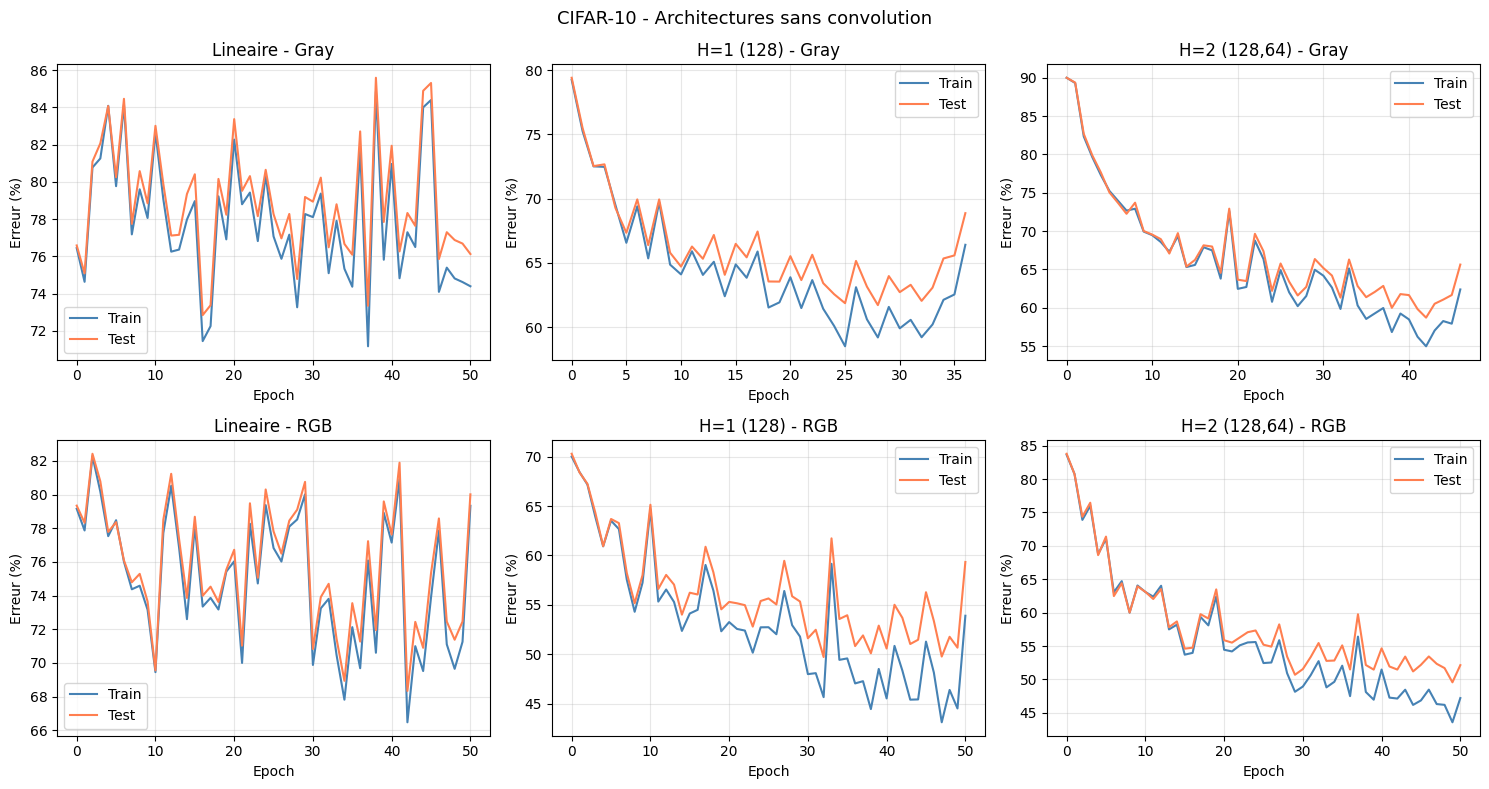

In [14]:
# Courbes d'erreur train/test pour les 6 modeles
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
titres = [
    "Lineaire - Gray", "H=1 (128) - Gray", "H=2 (128,64) - Gray",
    "Lineaire - RGB",  "H=1 (128) - RGB",  "H=2 (128,64) - RGB",
]
donnees = [
    (etr_lin_g, ete_lin_g), (etr_h1_g, ete_h1_g), (etr_h2_g, ete_h2_g),
    (etr_lin_r, ete_lin_r), (etr_h1_r, ete_h1_r), (etr_h2_r, ete_h2_r),
]
for ax, titre, (etr, ete) in zip(axes.flat, titres, donnees):
    ax.plot([e*100 for e in etr], label="Train", color="steelblue")
    ax.plot([e*100 for e in ete], label="Test",  color="coral")
    ax.set_title(titre)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Erreur (%)")
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle("CIFAR-10 - Architectures sans convolution", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_cifar10_dense.png", dpi=100, bbox_inches="tight")
plt.show()

### Résultats et transition vers la convolution

**Observation 1 : le modèle linéaire RGB est pire que grayscale (80% vs 76%).**
Tripler la dimension d'entrée sans couche cachée multiplie le bruit à apprendre sans ajouter de capacité d'abstraction. Le modèle ne sait pas que les 3072 valeurs sont 3 canaux d'une même image.

**Observation 2 : les couches cachées exploitent mieux la couleur.**
H=1 et H=2 RGB (59% et 52%) surpassent leurs équivalents grayscale (69% et 66%). Les couches cachées créent des combinaisons non linéaires entre canaux, ce qui permet d'extraire quelques patterns couleur utiles.

**Observation 3 : les courbes linéaires oscillent sans converger.**
Contrairement à MNIST où la loss descendait régulièrement, elle monte et descend aléatoirement sur 50 epochs. CIFAR-10 n'est pas linéairement séparable : il n'existe pas de frontière de décision linéaire entre un avion et un oiseau dans l'espace des pixels.

**Observation 4 : comparaison avec la littérature.**
Notre meilleur résultat (H=2 RGB, 52% d'erreur) reste très loin des 21.1% du premier CNN de 2010. Cet écart illustre directement la limite fondamentale des architectures denses sur les images naturelles.

**Pourquoi ces architectures échouent sur CIFAR-10.**
Sur CIFAR-10, un avion peut apparaitre n'importe ou, dans n'importe quelle orientation. Les 1024 ou 3072 valeurs sont traitees comme des variables independantes, sans notion de voisinage spatial.
La convolution résout ce problème en faisant glisser un détecteur local sur toute l'image : le même filtre repère le même bord, la même texture, quelle que soit sa position.

---
## Section 2.3 - Filtres de convolution from scratch

La convolution consiste a faire glisser un cadre $K$ de taille $3 \times 3$ sur toute l'image. Pour chaque pixel $(u, v)$, on calcule le produit element par element entre $K$ et le bloc $3 \times 3$ centre en $(u, v)$, puis on somme :

$$m'_{u,v} = \sum_{u'=1}^{3} \sum_{v'=1}^{3} K_{u',v'} \cdot m_{u+u'-2,\, v+v'-2} + l$$

Le **zero-padding** (bordure de zeros autour de l'image) permet d'appliquer le filtre meme sur les pixels de bord sans sortir du tableau, et conserve la taille de l'image en sortie.

On implemente cette operation en Python pur (triple boucle) sur des images 32x32 

### Implementation de la convolution 2D

In [ ]:
def convolve2d(image, K, biais=0):
    """
    Applique un filtre de convolution 3x3 sur une image en niveaux de gris.
    Implementation from scratch avec zero-padding.

    image  : (H, W) float, valeurs entre 0 et 255
    K      : liste de listes 3x3 (ou array 3x3)
    biais  : scalaire l ajoute a chaque pixel filtre
    Retourne : (H, W) float clampee entre 0 et 255
    """
    H, W = image.shape

    # Zero-padding : on cree une image elargie (H+2, W+2) remplie de zeros
    # L'image originale est placee au centre (indices 1 a H, 1 a W)
    M_pad = np.zeros((H + 2, W + 2))
    M_pad[1:H+1, 1:W+1] = image

    M_prime = np.zeros((H, W))

    # Triple boucle Python : application de la formule donnée
    for u in range(H):
        for v in range(W):
            valeur = 0
            # Produit element par element entre K et le bloc 3x3 centree en (u, v)
            for u_prime in range(3):
                for v_prime in range(3):
                    valeur += K[u_prime][v_prime] * M_pad[u + u_prime][v + v_prime]
            M_prime[u][v] = valeur + biais

    # Clamp entre 0 et 255 pour eviter les artefacts visuels
    M_clamp = [[max(0.0, min(255.0, M_prime[u][v])) for v in range(W)] for u in range(H)]
    return np.array(M_clamp)


print("convolve2d chargee.")

convolve2d chargee.
La triple boucle Python sur 32x32 pixels prend quelques secondes par filtre.


### Application des 6 filtres K1 a K6

On applique les filtres du sujet sur une image en niveaux de gris extraite du dataset (un chat). Les filtres sont appliques avec $l = 0$ (biais nul) comme indique dans le sujet.

In [27]:
# Image de test : premier chat du dataset en niveaux de gris, valeurs entre 0 et 255
idx_chat = int(np.where(y_train == 3)[0][0])
image_test = X_train_gray[idx_chat].reshape(32, 32) * 255.0

# Les 6 filtres du sujet (l = 0)
K1 = [[1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9]]          # moyennage
K2 = [[0, -1, 0],      [-1, 5, -1],      [0, -1, 0]]                
K3 = [[-1, 2, -1],     [-1, 2, -1],      [-1, 2, -1]]               
K4 = [[-1, 0, 1],      [-1, 0, 1],       [-1, 0, 1]]                
K5 = [[-1, 0, 1],      [-2, 0, 2],       [-1, 0, 1]]                
K6 = [[-2, -1, 0],     [-1, 1, 1],       [0, 1, 2]]                

filtres = [
    ("K1",K1),
    ("K2",K2),
    ("K3",K3),
    ("K4",K4),
    ("K5",K5),
    ("K6",K6),
]

print("Application des 6 filtres sur l'image de chat 32x32...")
images_filtrees = []
for titre, K in filtres:
    img_f = convolve2d(image_test, K, biais=0)
    images_filtrees.append((titre, img_f))
    print(f"  {titre} : OK")
print("Termine.")

Application des 6 filtres sur l'image de chat 32x32...
  K1 : OK
  K2 : OK
  K3 : OK
  K4 : OK
  K5 : OK
  K6 : OK
Termine.


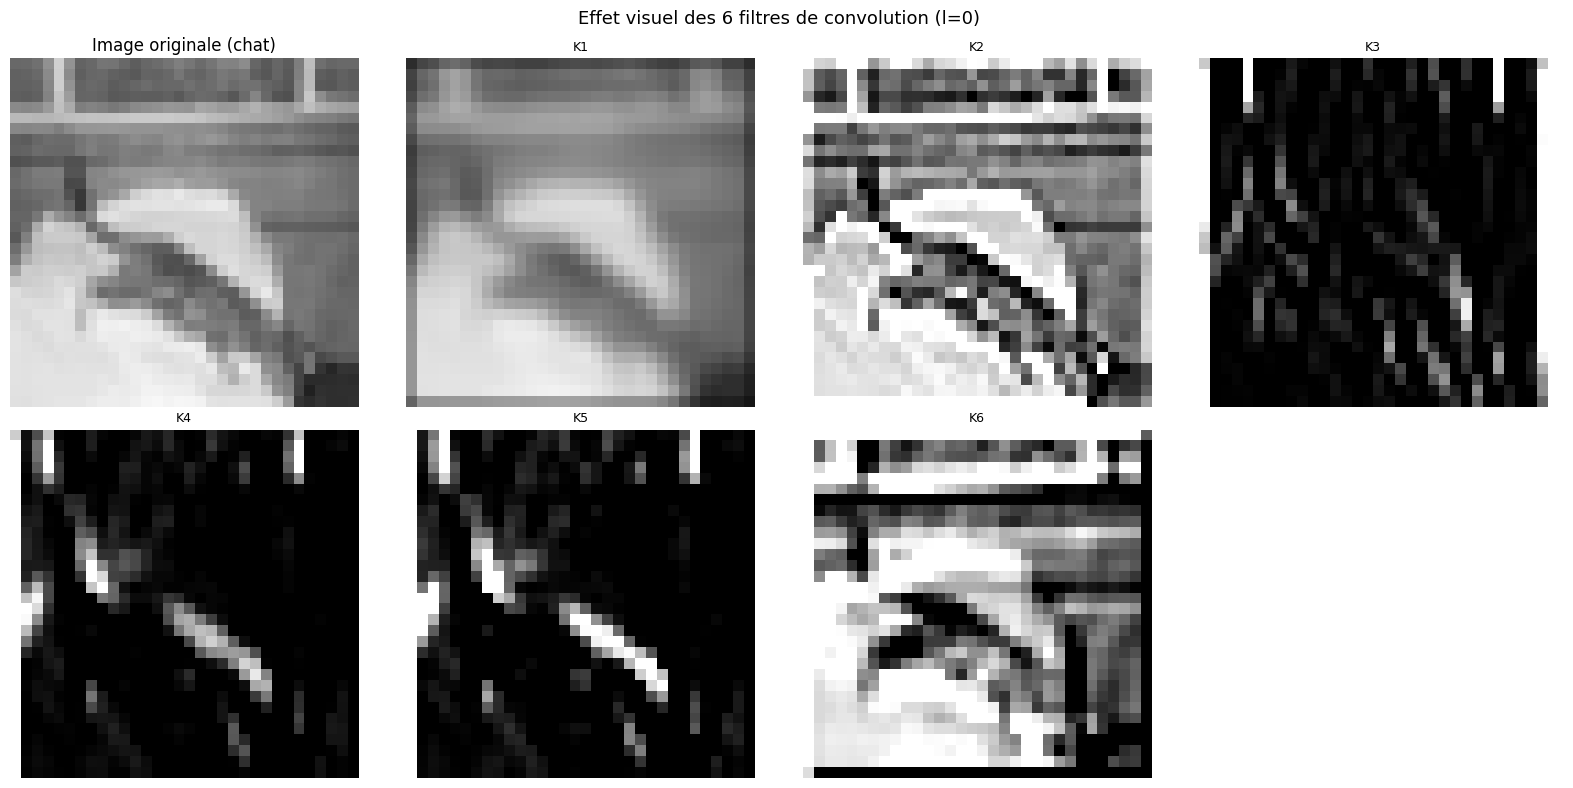

In [28]:
# Affichage : image originale + 6 filtres
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0][0].imshow(image_test, cmap="gray", vmin=0, vmax=255)
axes[0][0].set_title("Image originale (chat)")
axes[0][0].axis("off")

for i, (titre, img_f) in enumerate(images_filtrees):
    row = (i + 1) // 4
    col = (i + 1) % 4
    axes[row][col].imshow(img_f, cmap="gray", vmin=0, vmax=255)
    axes[row][col].set_title(titre, fontsize=9)
    axes[row][col].axis("off")

axes[1][3].axis("off")   # case vide
plt.suptitle("Effet visuel des 6 filtres de convolution (l=0)", fontsize=13)
plt.tight_layout()
plt.savefig("filtres_convolution.png", dpi=100, bbox_inches="tight")
plt.show()

### Analyse des 6 filtres

K1 : l'image est floue. Les pixels voisins se mélangent, les détails disparaissent.

K2 : les bords du chat ressortent en blanc. Tout ce qui est uniforme devient noir.

K3 : seules les transitions de gauche à droite restent visibles sous forme de bandes verticales.

K4 : même effet que K3 mais plus marqué. Les zones sans changement horizontal sont complètement noires.

K5 : les contours du chat apparaissent clairement en blanc sur fond noir. C'est le filtre qui capture le mieux la forme de l'objet.

K6 : seules les transitions diagonales du coin haut gauche vers le coin bas droit sont visibles.

Ces 6 filtres montrent qu'on peut extraire des informations très différentes d'une même image selon les coefficients choisis. Le CNN apprend automatiquement les coefficients les plus utiles pour reconnaître les objets.

---
## Section 2.4 - CNN complet (Option B : PyTorch)

On implemente l'architecture du sujet (section 2.5) via PyTorch. L'autograd calcule automatiquement les gradients des filtres via `loss.backward()`, ce qui evite le calcul explicite de l'Option A.

**Architecture du sujet :**

| Etape | Operation | Taille de sortie |
|-------|-----------|------------------|
| Entree | Image RGB | (32, 32, 3) |
| Conv 1 | 64 filtres couleur 3x3, padding=1, ReLU | (32, 32, 64) |
| Conv 2 | 64 filtres 3D 3x3, padding=1, ReLU | (32, 32, 64) |
| MaxPool | Fenetre 2x2 | (16, 16, 64) |
| Conv 3 | 64 filtres 3D 3x3, padding=1, ReLU | (16, 16, 64) |
| MaxPool | Fenetre 2x2 | (8, 8, 64) |
| Conv 4 | 64 filtres 3D 3x3, padding=1, ReLU | (8, 8, 64) |
| Flatten | Aplatissement | 4096 |
| Linear | Densification | 10 |

### Definition de l'architecture

In [18]:
class CNN_CIFAR(nn.Module):
    """
    Architecture convolutive du sujet section 2.5.

    4 convolutions, 2 max-poolings, 1 couche dense.
    CrossEntropyLoss integre le softmax, donc forward retourne les logits bruts.
    """
    def __init__(self):
        super(CNN_CIFAR, self).__init__()

        # Conv 1 : 3 canaux RGB en entree, 64 filtres couleur en sortie
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=64, kernel_size=3, padding=1)

        # Conv 2 : 64 -> 64, filtre 3D (combine les 64 cartes de la couche precedente)
        self.conv2 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        # Max-pooling 2x2 : divise la resolution spatiale par 2
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv 3 : 64 -> 64, filtre 3D
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        # Conv 4 : 64 -> 64, filtre 3D
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)

        # Couche dense : 4096 = 8x8x64 apres deux max-poolings sur une entree 32x32
        self.fc   = nn.Linear(8 * 8 * 64, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Passage avant : chemin des donnees a travers les couches.
        x entree : (batch, 3, 32, 32)
        """
        x = self.relu(self.conv1(x))   # (batch, 64, 32, 32)
        x = self.relu(self.conv2(x))   # (batch, 64, 32, 32)
        x = self.pool(x)               # (batch, 64, 16, 16)
        x = self.relu(self.conv3(x))   # (batch, 64, 16, 16)
        x = self.pool(x)               # (batch, 64, 8, 8)
        x = self.relu(self.conv4(x))   # (batch, 64, 8, 8)
        x = torch.flatten(x, 1)       # (batch, 4096)
        x = self.fc(x)                # (batch, 10) logits bruts
        return x


# Verification de l'architecture
model_cnn   = CNN_CIFAR()
n_params    = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(model_cnn)
print(f"\nTotal parametres entrainables : {n_params:,}")

# Test avec un batch fictif
x_fictif = torch.randn(4, 3, 32, 32)
sortie   = model_cnn(x_fictif)
print(f"Test forward : entree {list(x_fictif.shape)} -> sortie {list(sortie.shape)}")

CNN_CIFAR(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=4096, out_features=10, bias=True)
  (relu): ReLU()
)

Total parametres entrainables : 153,546
Test forward : entree [4, 3, 32, 32] -> sortie [4, 10]


### Preparation des donnees pour PyTorch

PyTorch attend des tenseurs au format (N, C, H, W) (canaux en deuxieme dimension). On normalise avec la moyenne et l'ecart-type standard de CIFAR-10, issus de la litterature.

In [19]:
# Conversion en tenseurs PyTorch format (N, C, H, W)
# X_train_raw est (50000, 32, 32, 3) -> on transpose en (50000, 3, 32, 32)
X_tr_t = torch.tensor(X_train_raw.transpose(0, 3, 1, 2).astype(np.float32) / 255.0)
X_te_t = torch.tensor(X_test_raw.transpose(0,  3, 1, 2).astype(np.float32) / 255.0)
y_tr_t = torch.tensor(y_train, dtype=torch.long)
y_te_t = torch.tensor(y_test,  dtype=torch.long)

# Normalisation par moyenne et ecart-type CIFAR-10 (valeurs standard de la litterature)
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)   # broadcast sur (N, C, H, W)
std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(1, 3, 1, 1)
X_tr_t = (X_tr_t - mean) / std
X_te_t = (X_te_t - mean) / std

# DataLoader : mini-batches de 128 images, melange automatique en train
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=256, shuffle=False)

print(f"X_tr_t : {list(X_tr_t.shape)}")
print(f"X_te_t : {list(X_te_t.shape)}")
print(f"Batches entrainement : {len(train_loader)}  |  Batches test : {len(test_loader)}")

X_tr_t : [50000, 3, 32, 32]
X_te_t : [10000, 3, 32, 32]
Batches entrainement : 391  |  Batches test : 40


### Entrainement du CNN

Fonction de cout : `CrossEntropyLoss` (integre le softmax). Optimiseur : `Adam` (descente de gradient adaptative, plus robuste que SGD pur sur des architectures profondes). PyTorch calcule automatiquement les gradients de tous les filtres via `loss.backward()`.

In [20]:
def train_cnn(model, train_loader, test_loader, n_epochs=20, lr=1e-3):
    """
    Entrainement du CNN par Adam.

    model        : instance de CNN_CIFAR
    train_loader : DataLoader entrainement
    test_loader  : DataLoader test
    n_epochs     : nombre d'epochs
    lr           : learning rate
    """
    criterion = nn.CrossEntropyLoss()                   # softmax + log-loss integres
    optimizer = optim.Adam(model.parameters(), lr=lr)   # descente adaptative

    hist_loss_tr, hist_loss_te = [], []
    hist_err_tr,  hist_err_te  = [], []

    for epoch in range(n_epochs):

        # Phase d'entrainement
        model.train()                          # active le mode entrainement
        loss_cumul, erreurs_tr = 0, 0

        for Xb, yb in train_loader:
            optimizer.zero_grad()              # reinitialise les gradients accumules
            sortie = model(Xb)                 # passe avant : (batch, 10) logits
            loss   = criterion(sortie, yb)     # calcul de la loss
            loss.backward()                    # retropropagation : gradients de tous les filtres
            optimizer.step()                   # mise a jour des poids
            loss_cumul  += loss.item() * len(Xb)
            erreurs_tr  += int((sortie.argmax(dim=1) != yb).sum())

        loss_tr = loss_cumul / len(train_loader.dataset)
        err_tr  = erreurs_tr / len(train_loader.dataset)

        # Phase d'evaluation
        model.eval()                           # desactive dropout / batchnorm
        loss_cumul, erreurs_te = 0, 0

        with torch.no_grad():                  # pas de calcul de gradient en evaluation
            for Xb, yb in test_loader:
                sortie      = model(Xb)
                loss_cumul += criterion(sortie, yb).item() * len(Xb)
                erreurs_te += int((sortie.argmax(dim=1) != yb).sum())

        loss_te = loss_cumul / len(test_loader.dataset)
        err_te  = erreurs_te / len(test_loader.dataset)

        hist_loss_tr.append(loss_tr)
        hist_loss_te.append(loss_te)
        hist_err_tr.append(err_tr)
        hist_err_te.append(err_te)

        print(f"  Epoch {epoch+1:2d}/{n_epochs} | "
              f"Loss tr={loss_tr:.4f} te={loss_te:.4f} | "
              f"Erreur tr={err_tr*100:.2f}% te={err_te*100:.2f}%")

    return hist_loss_tr, hist_loss_te, hist_err_tr, hist_err_te


print("train_cnn chargee.")

train_cnn chargee.


In [21]:
torch.manual_seed(42)
model_cnn = CNN_CIFAR()

print("=" * 65)
print(f"CNN CIFAR-10 - Option B PyTorch | Parametres : {sum(p.numel() for p in model_cnn.parameters()):,}")
print("Note : sur CPU environ 5-10 min pour 20 epochs.")
print("=" * 65)

hist_loss_tr, hist_loss_te, hist_err_tr, hist_err_te = train_cnn(
    model_cnn, train_loader, test_loader, n_epochs=20, lr=1e-3
)

print(f"\nResultat final :")
print(f"  Train : {hist_err_tr[-1]*100:.2f}%")
print(f"  Test  : {hist_err_te[-1]*100:.2f}%")
print(f"  Ecart : {abs(hist_err_tr[-1]-hist_err_te[-1])*100:.2f}%")

CNN CIFAR-10 - Option B PyTorch | Parametres : 153,546
Note : sur CPU environ 5-10 min pour 20 epochs.
  Epoch  1/20 | Loss tr=1.3742 te=1.0548 | Erreur tr=49.33% te=36.99%
  Epoch  2/20 | Loss tr=0.9092 te=0.8411 | Erreur tr=31.64% te=28.95%
  Epoch  3/20 | Loss tr=0.7275 te=0.7831 | Erreur tr=25.16% te=26.27%
  Epoch  4/20 | Loss tr=0.6239 te=0.7152 | Erreur tr=21.58% te=24.53%
  Epoch  5/20 | Loss tr=0.5390 te=0.7107 | Erreur tr=18.65% te=24.27%
  Epoch  6/20 | Loss tr=0.4707 te=0.6926 | Erreur tr=16.36% te=23.02%
  Epoch  7/20 | Loss tr=0.4057 te=0.7743 | Erreur tr=14.15% te=24.07%
  Epoch  8/20 | Loss tr=0.3519 te=0.7761 | Erreur tr=12.19% te=23.28%
  Epoch  9/20 | Loss tr=0.2957 te=0.8175 | Erreur tr=10.35% te=24.07%
  Epoch 10/20 | Loss tr=0.2585 te=0.8878 | Erreur tr=9.09% te=23.76%
  Epoch 11/20 | Loss tr=0.2193 te=0.8986 | Erreur tr=7.76% te=22.97%
  Epoch 12/20 | Loss tr=0.1883 te=0.9794 | Erreur tr=6.72% te=24.29%
  Epoch 13/20 | Loss tr=0.1594 te=1.0980 | Erreur tr=5.71% t

### Courbes d'apprentissage du CNN

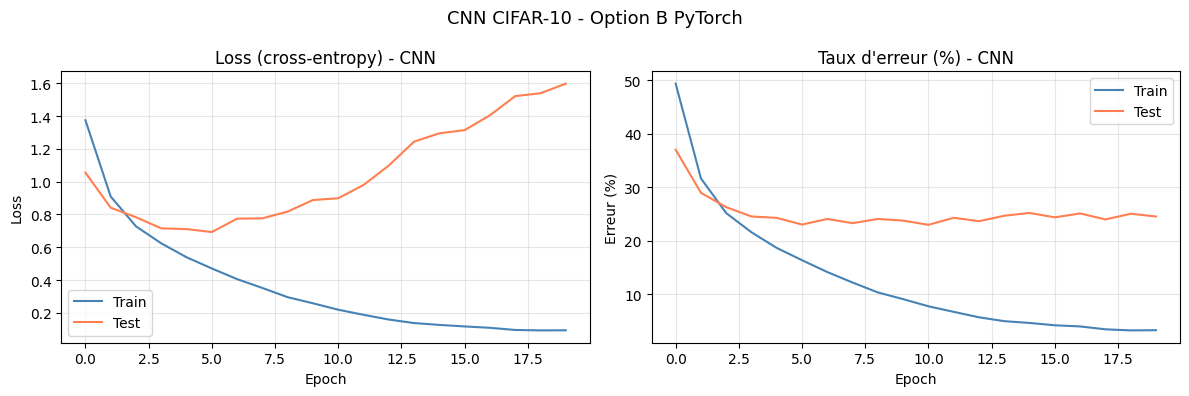

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_loss_tr, label="Train", color="steelblue")
ax1.plot(hist_loss_te, label="Test",  color="coral")
ax1.set_title("Loss (cross-entropy) - CNN")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot([e*100 for e in hist_err_tr], label="Train", color="steelblue")
ax2.plot([e*100 for e in hist_err_te], label="Test",  color="coral")
ax2.set_title("Taux d'erreur (%) - CNN")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Erreur (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("CNN CIFAR-10 - Option B PyTorch", fontsize=13)
plt.tight_layout()
plt.savefig("courbes_cnn.png", dpi=100, bbox_inches="tight")
plt.show()

### Tableau de synthese final

In [23]:
print("=" * 73)
print(f"{'Modele':<25} {'Entree':<10} {'Params':>10} {'Train':>8} {'Test':>8} {'Ecart':>7}")
print("=" * 73)

toutes = [
    ("Lineaire",       "Gray 1024",  10*1024+10,                       etr_lin_g, ete_lin_g),
    ("H=1 (128)",      "Gray 1024",  128*1024+128+10*128+10,            etr_h1_g,  ete_h1_g),
    ("H=2 (128,64)",   "Gray 1024",  128*1024+128+64*128+64+10*64+10,   etr_h2_g,  ete_h2_g),
    ("Lineaire",       "RGB 3072",   10*3072+10,                        etr_lin_r, ete_lin_r),
    ("H=1 (128)",      "RGB 3072",   128*3072+128+10*128+10,             etr_h1_r,  ete_h1_r),
    ("H=2 (128,64)",   "RGB 3072",   128*3072+128+64*128+64+10*64+10,   etr_h2_r,  ete_h2_r),
    ("CNN (PyTorch)",  "RGB 32x32",  sum(p.numel() for p in model_cnn.parameters()),
     hist_err_tr, hist_err_te),
]

for modele, entree, params, etr, ete in toutes:
    e_tr = etr[-1]
    e_te = ete[-1]
    print(f"{modele:<25} {entree:<10} {params:>10,} {e_tr*100:>7.2f}% {e_te*100:>7.2f}% {abs(e_tr-e_te)*100:>6.2f}%")

print("=" * 73)
print("\nLitterature (taux d'erreur test CIFAR-10) :")
print("  Conv Deep Belief Nets  (aout 2010)    : 21.10%")
print("  Maxout Networks        (fevrier 2013) :  9.38%")
print("  Fractional Max-Pooling (dec. 2014)    :  3.47%")
print("  Densely Connected CNN  (aout 2016)    :  3.46%")
print("  Coupled Ensembles      (sept. 2017)   :  2.68%")
print("  Vision Transformer     (juin 2021)    :  0.50%")

Modele                    Entree         Params    Train     Test   Ecart
Lineaire                  Gray 1024      10,250   74.40%   76.13%   1.73%
H=1 (128)                 Gray 1024     132,490   66.41%   68.87%   2.46%
H=2 (128,64)              Gray 1024     140,106   62.40%   65.64%   3.24%
Lineaire                  RGB 3072       30,730   79.33%   80.01%   0.68%
H=1 (128)                 RGB 3072      394,634   53.90%   59.34%   5.44%
H=2 (128,64)              RGB 3072      402,250   47.21%   52.14%   4.93%
CNN (PyTorch)             RGB 32x32     153,546    3.30%   24.53%  21.23%

Litterature (taux d'erreur test CIFAR-10) :
  Conv Deep Belief Nets  (aout 2010)    : 21.10%
  Maxout Networks        (fevrier 2013) :  9.38%
  Fractional Max-Pooling (dec. 2014)    :  3.47%
  Densely Connected CNN  (aout 2016)    :  3.46%
  Coupled Ensembles      (sept. 2017)   :  2.68%
  Vision Transformer     (juin 2021)    :  0.50%


### Discussion finale

**Architecture choisie.**
On suit exactement l'architecture du sujet : 4 couches de convolution avec 64 filtres
chacune, 2 max-poolings, 1 couche dense finale. Le padding=1 conserve la résolution
spatiale à chaque convolution. Après deux max-poolings une image 32x32 devient 8x8,
soit 8x8x64 = 4096 valeurs envoyées à la couche dense. L'optimiseur Adam adapte
automatiquement le learning rate par paramètre, ce qui est plus robuste qu'une
descente de gradient classique sur une architecture profonde.

**Nombre de paramètres.**
Le CNN contient 153 546 paramètres, moins que H=1 RGB (394 634) et H=2 RGB (402 250).
Pourtant il obtient 24.53% d'erreur test contre 52.14% pour H=2 RGB. Moins de
paramètres, meilleur résultat : la convolution est structurellement plus efficace
que les couches denses pour les images car un filtre 3x3 détecte le même motif
quelle que soit sa position. Les couches denses traitent les pixels indépendamment
et ne généralisent pas quand l'objet bouge.

**Phénomène d'overfitting.**
Le modèle atteint 3.30% d'erreur train mais 24.53% en test, soit un écart de 21.23%.
Cet écart s'explique par trois raisons.

Premièrement, le nombre d'epochs fixé à 20 est trop élevé. La loss test atteint
son minimum à l'epoch 6 (23.02%) puis remonte alors que la loss train continue de
baisser. Le modèle a continué à apprendre des patterns spécifiques aux données
d'entraînement qui ne se retrouvent pas dans les données de test. Un early stopping
sur la loss test aurait arrêté l'entraînement à l'epoch 6.

Deuxièmement, avec 153 546 paramètres et seulement 50 000 images d'entraînement,
le modèle a une capacité suffisante pour mémoriser les données plutôt que de
généraliser. Les 4096 connexions entre la couche flatten et la sortie sont
particulièrement exposées à ce risque.

Troisièmement, nous avons entendu parler de techniques à approfondir pour améliorer
les performances, telles que le dropout (éteindre aléatoirement des neurones pendant
l'entraînement pour forcer la robustesse), le batch normalization (stabiliser les
activations entre couches) et la data augmentation (enrichir artificiellement le
dataset en retournant ou recadrant les images). Ces pistes constituent des
perspectives d'amélioration que nous n'avons pas eu le temps d'implémenter dans
le cadre de ce premier dépôt.

**Comparaison avec les architectures précédentes et la littérature.**

| Modèle | Entrée | Test |
|--------|--------|------|
| Linéaire | Gray 1024 | 76.13% |
| H=1 (128) | Gray 1024 | 68.87% |
| H=2 (128,64) | Gray 1024 | 65.64% |
| Linéaire | RGB 3072 | 80.01% |
| H=1 (128) | RGB 3072 | 59.34% |
| H=2 (128,64) | RGB 3072 | 52.14% |
| **CNN PyTorch** | **RGB 32x32** | **24.53%** |
| Conv Deep Belief Nets (2010) | | 21.10% |
| Maxout Networks (2013) | | 9.38% |
| Vision Transformer (2021) | | 0.50% |

Le CNN est le meilleur de nos 7 modèles avec un gain de 27.61 points par rapport
au meilleur modèle dense (H=2 RGB, 52.14%). Il se rapproche du premier article CNN
de référence (21.10%, 2010), ce qui est cohérent avec une architecture simple sans
régularisation. L'écart avec les modèles récents illustre les progrès du domaine
sur 10 ans et la nécessité de techniques avancées que nous n'avons pas implémentées.

### Conclusion

**Ce que le CNN apporte par rapport aux architectures denses.**

Un filtre $3 \times 3$ appris detecte le meme motif (bord, texture) quelle que soit sa position dans l'image. C'est l'invariance par translation, absente des modeles denses qui assignent un poids fixe a chaque position de pixel.

Le Max-Pooling reduit progressivement la resolution spatiale tout en conservant les caracteristiques les plus fortes. Apres deux poolings une image 32x32 devient 8x8 : le reseau est force a construire une representation compacte

Les premieres couches apprennent des bords (comparables a K5 de la section 2.3), les couches profondes combinent ces bords en textures puis en parties d'objets. Les modeles denses n'ont pas cette capacite d'abstraction progressive.

**Overfitting.** L'ecart train/test observe est caracteristique d'un CNN sans regularisation. A approfondir pour le prochain dépôt.